In [1]:
%cd /iridisfs/home/lhl1g23/ssm/mamba

/iridisfs/home/lhl1g23/ssm/mamba


In [2]:
from models.dataloaders.dataloaders import get_cifar
train, test = get_cifar()

x, y = next(iter(train))
x,y = x.to("cuda"), y.to("cuda")

In [15]:
from train.train import MambaClassifierTrainer
from omegaconf import OmegaConf
import torch
import matplotlib.pyplot as plt

patch_size = 4

cfg = OmegaConf.load(f"models/configs/cifar/cifar_{patch_size}_patchsize.yaml")
model = MambaClassifierTrainer.load_from_checkpoint(
    f"checkpoints/cifar/{patch_size}_patchsize_2500_epochs/last.ckpt",
    data="cifar",
    model_config=cfg.model
)

with torch.no_grad():
    model.eval()
    
    pred = torch.argmax(model(x), dim=1)
    
    A, B, C, D, dt, dA, dB, states, y_ssm = next(model.classifier.get_parameters(x))
    print(
f"""
A: {A.shape} 
B: {B.shape}
C: {C.shape} 
D: {D.shape}
delta: {dt.shape}
discrete A: {dA.shape} 
discrete B: {dB.shape}
states: {states.shape}
y: {y_ssm.shape}"""

)


A: torch.Size([256, 16]) 
B: torch.Size([32, 64, 16])
C: torch.Size([32, 64, 16]) 
D: torch.Size([256])
delta: torch.Size([32, 64, 256])
discrete A: torch.Size([32, 64, 256, 16]) 
discrete B: torch.Size([32, 64, 256, 16])
states: torch.Size([32, 64, 256, 16])
y: torch.Size([32, 64, 256])


In [16]:
""" model = MambaClassifierTrainer(cfg.model, "cifar").to("cuda")
with torch.no_grad():
    model.eval()
    
    pred = torch.argmax(model(x), dim=1)
    
    A, B, C, D, dt, dA, dB, states, y_ssm = next(model.classifier.get_parameters(x)) """

' model = MambaClassifierTrainer(cfg.model, "cifar").to("cuda")\nwith torch.no_grad():\n    model.eval()\n    \n    pred = torch.argmax(model(x), dim=1)\n    \n    A, B, C, D, dt, dA, dB, states, y_ssm = next(model.classifier.get_parameters(x)) '

In [17]:
""" c=0
total = 0

for X, Y in train:
    X,Y = X.to("cuda"), Y.to("cuda")
    c += torch.count_nonzero(torch.argmax(model(X), dim=1) == Y)
    total += len(Y)
    
acc = c/total
acc """

' c=0\ntotal = 0\n\nfor X, Y in train:\n    X,Y = X.to("cuda"), Y.to("cuda")\n    c += torch.count_nonzero(torch.argmax(model(X), dim=1) == Y)\n    total += len(Y)\n    \nacc = c/total\nacc '

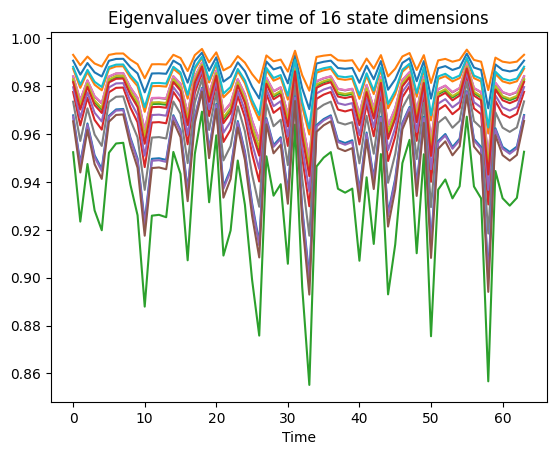

In [18]:
b,l,d,n = dA.shape
sample = 6

x_axis = range(0,l)
for i in range(n):
    if i < 32:
        y_axis = dA[sample,:,0,i]

        plt.plot(y_axis, label=i)

plt.xlabel("Time")
plt.title("Eigenvalues over time of 16 state dimensions")
""" plt.legend() """
plt.show()

In [19]:
def normalised_sum(x):
    row_means = x.mean(dim=1, keepdim=True)
    centered = x - row_means
    row_max = centered.max(dim=1, keepdim=True).values
    row_max = torch.where(row_max == 0, torch.tensor(1.0), row_max)
    normalised = centered / row_max
    result = normalised.sum(dim=1)
    return result

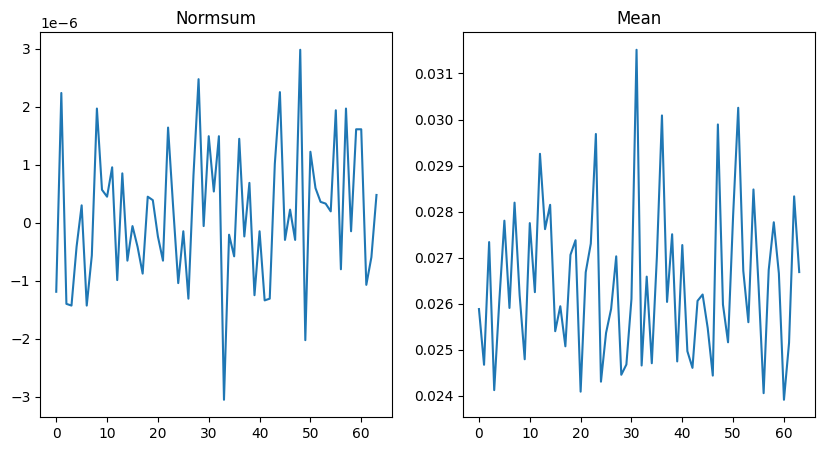

In [20]:
dt_normsum = normalised_sum(dt[sample])
dt_mean = torch.mean(dt[sample], dim=1)
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(dt_normsum[:])
ax[0].set_title("Normsum")
ax[1].plot(dt_mean[:])
ax[1].set_title("Mean")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6018695..1.9797254].


Label: frog
Prediction: frog


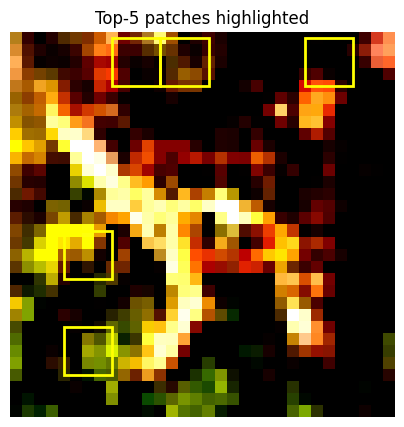

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

topk = torch.topk(-dt_normsum, 5).indices
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
print(f"Label: {labels[y[sample]]}")
print(f"Prediction: {labels[pred[sample]]}")

# Convert tensor to image
img = x[sample].cpu().permute(1, 2, 0).numpy()

H, W, _ = img.shape
num_h = H // patch_size
num_w = W // patch_size

fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(img)

# Highlight each patch in topk (e.g., top 5 most important)
for n in topk.tolist():          # convert tensor → list
    i = n // num_w               # row index
    j = n % num_w                # column index

    rect = patches.Rectangle(
        (j * patch_size, i * patch_size),
        patch_size,
        patch_size,
        linewidth=2,
        edgecolor='yellow',
        facecolor='none'
    )
    ax.add_patch(rect)

ax.set_title(f"Top-{len(topk)} patches highlighted")
ax.axis("off")
plt.show()


In [22]:
""" from einops.layers.torch import Rearrange

masks = [4]
rearrange = Rearrange(
            'b c (h p1) (w p2) -> b (h w) (c p1 p2)',
            p1=patch_size, p2=patch_size
        ) 
rearrange_ori = Rearrange(
            'b (h w) (c p1 p2) -> b c (h p1) (w p2)',
            p1=patch_size, p2=patch_size, h=32//patch_size, w=32//patch_size
        ) 
x_re = rearrange(x)
for m in masks:
    x_re[sample, m, :] = 0
x_ori = rearrange_ori(x_re)
print(torch.argmax(model(x_ori), dim=1)[sample])

img = x_ori[sample].cpu().permute(1, 2, 0).numpy()
plt.imshow(img)
plt.show() """

" from einops.layers.torch import Rearrange\n\nmasks = [4]\nrearrange = Rearrange(\n            'b c (h p1) (w p2) -> b (h w) (c p1 p2)',\n            p1=patch_size, p2=patch_size\n        ) \nrearrange_ori = Rearrange(\n            'b (h w) (c p1 p2) -> b c (h p1) (w p2)',\n            p1=patch_size, p2=patch_size, h=32//patch_size, w=32//patch_size\n        ) \nx_re = rearrange(x)\nfor m in masks:\n    x_re[sample, m, :] = 0\nx_ori = rearrange_ori(x_re)\nprint(torch.argmax(model(x_ori), dim=1)[sample])\n\nimg = x_ori[sample].cpu().permute(1, 2, 0).numpy()\nplt.imshow(img)\nplt.show() "

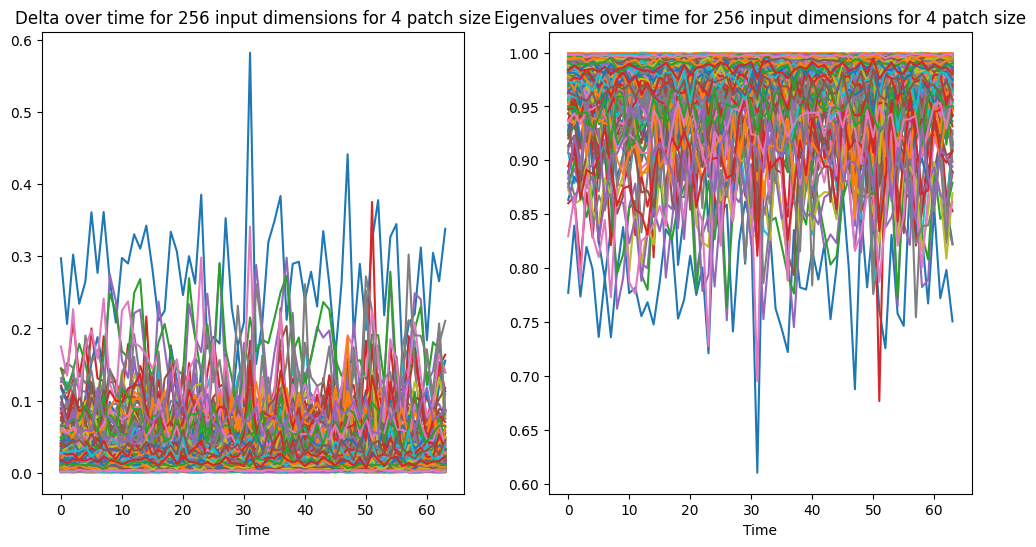

In [23]:
start = 0
n_din = 256
fig, ax = plt.subplots(1,2, figsize=(12,6))

with torch.no_grad():
    b,l,d,n = dA.shape
    for i in range(start, start + n_din):
        y_axis = dt[sample,:,i]
        ax[0].plot(y_axis)
            
    for i in range(start, start + n_din):
        y_axis = dA[sample,:,i,0]
        ax[1].plot(y_axis)

ax[0].set_xlabel("Time")
ax[0].set_title(f"Delta over time for {n_din} input dimensions for {patch_size} patch size")
ax[1].set_xlabel("Time")
ax[1].set_title(f"Eigenvalues over time for {n_din} input dimensions for {patch_size} patch size")
plt.show()

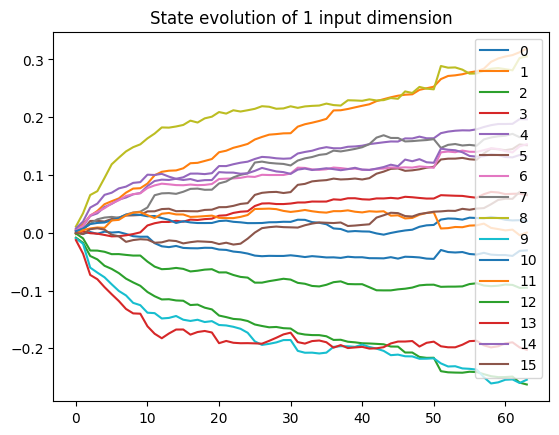

In [24]:
for i in range(n):
    plt.plot(states[sample,:,123,i].to("cpu"), label=i)
plt.title("State evolution of 1 input dimension")
plt.legend()
plt.show()